# 220119 F2 run11: Cluster, Clean, and Reconstruct

Stage 2 for the restarted V2a workflow. This notebook loads the saved decomposition artifacts from `decompositions.ipynb`, clusters IC spectra, ranks clusters in the configured low-frequency band, reconstructs cleaned traces from accepted clusters, and saves auditable cluster selections plus descriptive trace-preservation metrics.

This full-recording clustering is for exploration, visualization, and candidate generation. Use `behavior_decoding.ipynb` for leakage-safe fold-local behavior and causal-state evidence.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")


from ica_denoising.behavior_decoding import TraceVariant, summarize_trace_preservation
from ica_denoising.bss_notebook import (
    BSS_METHODS,
    cleaned_trace_output_paths,
    load_bss_decomposition_outputs,
    load_traces,
    save_cleaned_trace_output,
    save_cluster_selection_output,
)
from ica_denoising.core.ica_utils import (
    cluster,
    plot_mean_log_psd_by_cluster,
    rank_clusters_by_mean_log_psd,
    reconstruct_bss,
)
from ica_denoising.core.visualization import plot_clusters


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


In [2]:
DATASET_KEY = "v2a-RSNs/220127_F4_run2_fluorescence"
METHODS_TO_RUN = list(BSS_METHODS) # ["fastica", "infomax"] 
N_CLUSTERS = 7
FEATURE_START_BIN = 30
WELCH_NPERSEG = 250
WELCH_NOVERLAP = 125
RANKING_FMIN_HZ = 0.0
RANKING_FMAX_HZ = 0.20
RANKING_AGGREGATE = "peak"
KEEP_TOP_CLUSTER_COUNT = 2
RANDOM_STATE = 0
PLOT_DPI = 300
SAVE_OUTPUTS = True


In [3]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = dataset.recording_id or dataset.data_name
sample_rate_hz = float(dataset.sample_rate_hz)
results = {}
skipped = {}
for method in METHODS_TO_RUN:
    try:
        results[method] = load_bss_decomposition_outputs(
            DATASET_KEY,
            method,
            PROJECT_ROOT,
            output_data_name_override=OUTPUT_DATA_NAME,
        )
    except FileNotFoundError as error:
        skipped[method] = str(error).splitlines()[0]

if not results:
    raise FileNotFoundError("No saved decompositions found. Run decompositions.ipynb first.")
dataset_output_dir = next(iter(results.values())).output_dir.parent
figure_dir = dataset_output_dir / "figures"
if SAVE_OUTPUTS:
    figure_dir.mkdir(parents=True, exist_ok=True)
print(f"Dataset: {dataset.key}")
print(f"Loaded methods: {list(results)}")
print(f"Skipped methods: {skipped}")
print(f"Dataset output directory: {dataset_output_dir.relative_to(PROJECT_ROOT)}")


Dataset: v2a-RSNs/220127_F4_run2_fluorescence
Loaded methods: ['fastica', 'infomax', 'sobi', 'jade']
Skipped methods: {}
Dataset output directory: outputs/linear/v2a-RSNs/220127_F4_run2


In [4]:
def cluster_detail_records(labels, ranking, accepted_clusters):
    labels = np.asarray(labels)
    accepted_set = {int(cluster_id) for cluster_id in accepted_clusters}
    ranking_by_cluster = {int(row["cluster"]): row for row in ranking}
    cluster_records = []
    component_records = []
    for label in sorted(np.unique(labels).astype(int).tolist()):
        component_indices = np.flatnonzero(labels == label).astype(int).tolist()
        rank_row = ranking_by_cluster.get(label, {})
        rank = rank_row.get("rank")
        score = rank_row.get("score")
        accepted = label in accepted_set
        cluster_records.append(
            {
                "cluster": int(label),
                "rank": None if rank is None else int(rank),
                "score": None if score is None else float(score),
                "n_components": len(component_indices),
                "accepted": bool(accepted),
                "component_indices": component_indices,
            }
        )
        for component in component_indices:
            component_records.append(
                {
                    "component": int(component),
                    "cluster": int(label),
                    "cluster_rank": None if rank is None else int(rank),
                    "cluster_score": None if score is None else float(score),
                    "accepted": bool(accepted),
                }
            )
    return cluster_records, component_records


cluster_results = {}
ranking_rows = []
cluster_membership_rows = []
for method, result in results.items():
    embedding, labels, spectra, features = cluster(
        result.ic_comps,
        N_CLUSTERS,
        sample_rate_hz,
        feature_start_bin=FEATURE_START_BIN,
        nperseg=WELCH_NPERSEG,
        noverlap=WELCH_NOVERLAP,
        random_state=RANDOM_STATE,
    )
    ranking = rank_clusters_by_mean_log_psd(
        spectra,
        labels,
        sample_rate_hz,
        fmin=RANKING_FMIN_HZ,
        fmax=RANKING_FMAX_HZ,
        aggregate=RANKING_AGGREGATE,
    )
    rank_order = [int(row["cluster"]) for row in ranking]
    cluster_results[method] = {
        "embedding": embedding,
        "new_mat": embedding,
        "labels": labels,
        "predictions": labels,
        "spectra": spectra,
        "features": features,
        "ranking": ranking,
        "rank_order": rank_order,
    }
    ranking_rows.extend({"method": method, **row} for row in ranking)
    for cluster_id in sorted(np.unique(labels).astype(int).tolist()):
        ic_indices = np.flatnonzero(labels == cluster_id).astype(int).tolist()
        cluster_membership_rows.append(
            {
                "method": method,
                "cluster": int(cluster_id),
                "n_components": len(ic_indices),
                "component_indices": ic_indices,
            }
        )
    print(f"{method}: cluster rank order = {rank_order}")

cluster_ranking = pd.DataFrame(ranking_rows)
cluster_membership = pd.DataFrame(cluster_membership_rows)
cluster_ranking_path = dataset_output_dir / "cluster_ranking.csv"
cluster_membership_path = dataset_output_dir / "cluster_membership.csv"
if SAVE_OUTPUTS:
    cluster_ranking.to_csv(cluster_ranking_path, index=False)
    cluster_membership.to_csv(cluster_membership_path, index=False)
    print(f"Saved cluster ranking: {cluster_ranking_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved cluster membership: {cluster_membership_path.relative_to(PROJECT_ROOT)}")
cluster_ranking


fastica: cluster rank order = [6, 1, 5, 2, 3, 4, 0]
infomax: cluster rank order = [5, 1, 3, 6, 4, 2, 0]
sobi: cluster rank order = [2, 0, 6, 5, 3, 1, 4]
jade: cluster rank order = [4, 1, 6, 0, 2, 5, 3]
Saved cluster ranking: outputs/linear/v2a-RSNs/220127_F4_run2/cluster_ranking.csv
Saved cluster membership: outputs/linear/v2a-RSNs/220127_F4_run2/cluster_membership.csv


,method,cluster,score,n_components,rank
0,fastica,6,1.955462,7,1
1,fastica,1,1.868973,8,2
2,fastica,5,1.555320,15,3
3,fastica,2,0.963313,7,4
4,fastica,3,0.354908,16,5
5,fastica,4,0.290162,12,6
6,fastica,0,0.090016,27,7
7,infomax,5,2.218699,7,1
8,infomax,1,1.763013,3,2
9,infomax,3,1.312762,8,3


Saved cluster diagnostics for fastica: outputs/linear/v2a-RSNs/220127_F4_run2/fastica/clusters/cluster_diagnostics_fastica_220127_F4_run2_fluorescence.png


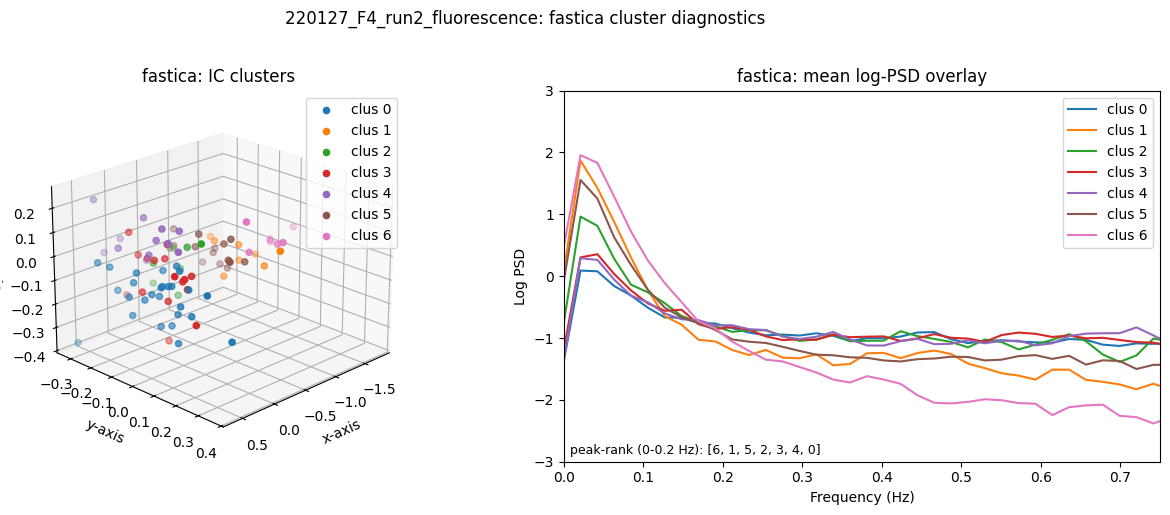

Saved cluster diagnostics for infomax: outputs/linear/v2a-RSNs/220127_F4_run2/infomax/clusters/cluster_diagnostics_infomax_220127_F4_run2_fluorescence.png


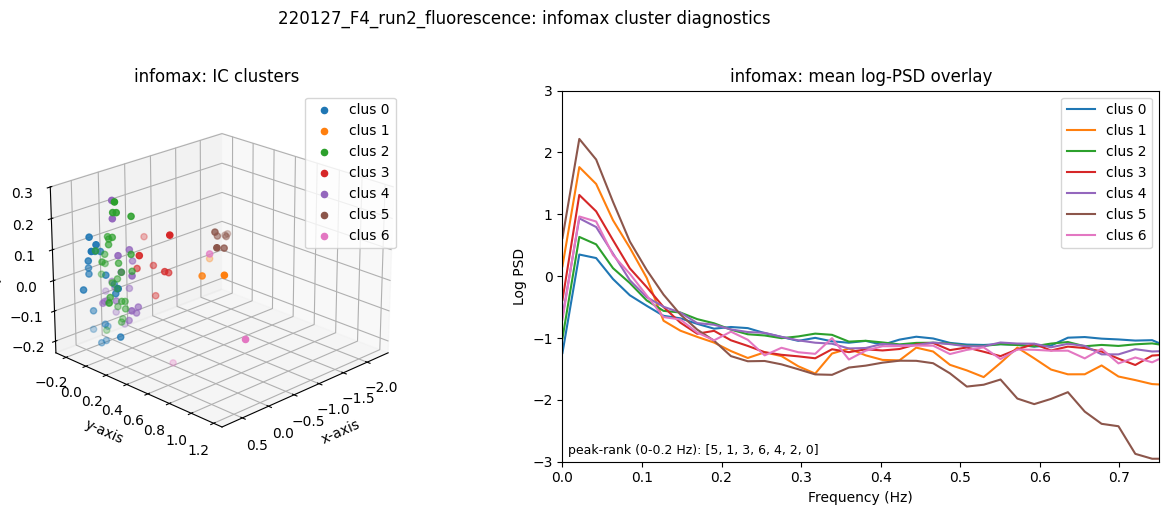

Saved cluster diagnostics for sobi: outputs/linear/v2a-RSNs/220127_F4_run2/sobi/clusters/cluster_diagnostics_sobi_220127_F4_run2_fluorescence.png


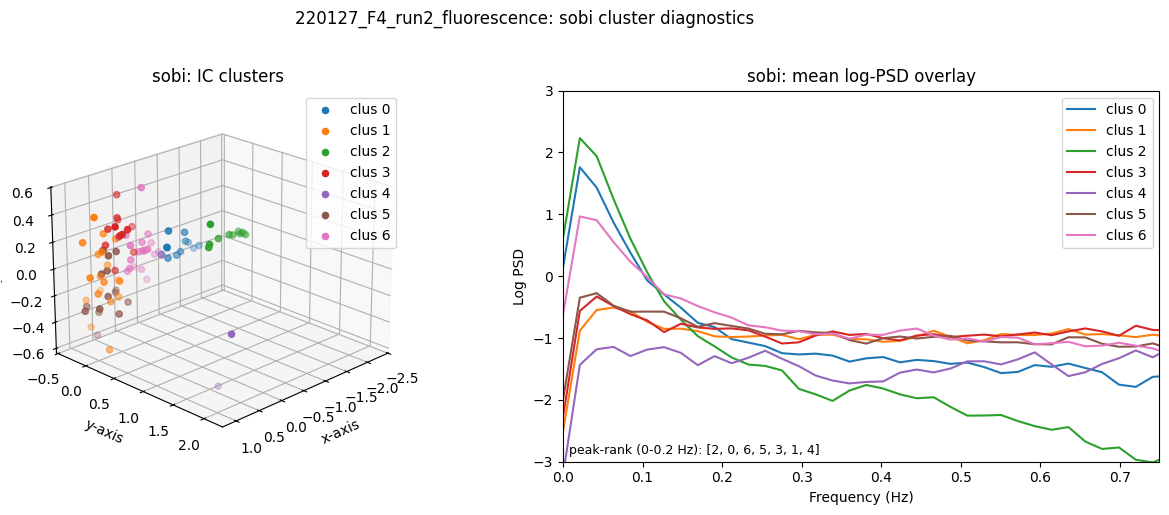

Saved cluster diagnostics for jade: outputs/linear/v2a-RSNs/220127_F4_run2/jade/clusters/cluster_diagnostics_jade_220127_F4_run2_fluorescence.png


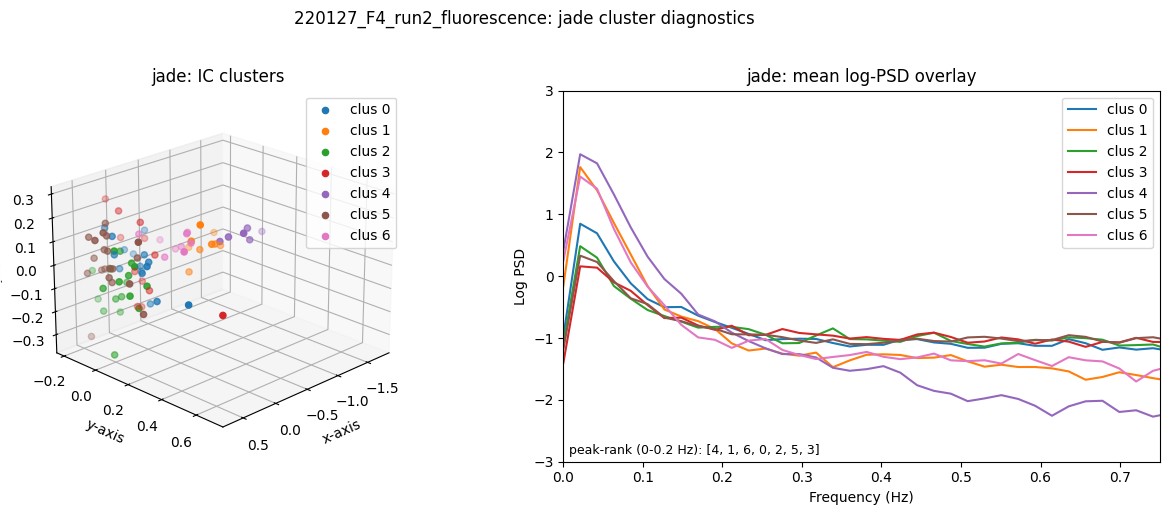

In [5]:
def plot_cluster_diagnostics(embedding, labels, spectra, method, rank_order):
    fig = plt.figure(figsize=(13, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.0])

    ax3d = fig.add_subplot(gs[0, 0], projection="3d")
    for label in np.unique(labels):
        points = embedding[labels == label]
        ax3d.scatter(points[:, 0], points[:, 1], points[:, 2], label=f"clus {int(label)}")
    ax3d.set_xlabel("x-axis")
    ax3d.set_ylabel("y-axis")
    ax3d.set_zlabel("z-axis")
    ax3d.set_title(f"{method}: IC clusters")
    ax3d.legend(loc="best")
    ax3d.view_init(elev=22, azim=45)

    ax_psd = fig.add_subplot(gs[0, 1])
    eps = np.finfo(float).eps
    freqs = np.linspace(0.0, float(sample_rate_hz) / 2.0, spectra.shape[1])
    for label in np.unique(labels):
        group = spectra[labels == label]
        mean_log = np.log(np.maximum(group.mean(axis=0), eps))
        ax_psd.plot(freqs, mean_log, lw=1.5, label=f"clus {int(label)}")
    ax_psd.set_xlim([0.0, min(0.75, sample_rate_hz / 2.0)])
    ax_psd.set_ylim([-3.0, 3.0])
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("Log PSD")
    ax_psd.set_title(f"{method}: mean log-PSD overlay")
    ax_psd.text(
        0.01,
        0.02,
        f"peak-rank ({RANKING_FMIN_HZ:g}-{RANKING_FMAX_HZ:g} Hz): {rank_order}",
        transform=ax_psd.transAxes,
        fontsize=9,
    )
    ax_psd.legend(loc="best")

    fig.suptitle(f"{dataset.data_name}: {method} cluster diagnostics", y=1.02)
    fig.tight_layout()
    return fig


figure_paths = {}
cluster_figure_paths_by_method = {}
for method, clustered in cluster_results.items():
    result = results[method]
    method_cluster_dir = result.output_dir / "clusters"
    if SAVE_OUTPUTS:
        method_cluster_dir.mkdir(parents=True, exist_ok=True)

    stem = f"{method}_{dataset.data_name}"
    fig = plot_cluster_diagnostics(
        clustered["embedding"],
        clustered["labels"],
        clustered["spectra"],
        method,
        clustered["rank_order"],
    )
    diagnostics_path = method_cluster_dir / f"cluster_diagnostics_{stem}.png"
    manuscript_diagnostics_path = figure_dir / f"cluster_diagnostics_{stem}.png"

    if SAVE_OUTPUTS:
        fig.savefig(diagnostics_path, dpi=PLOT_DPI, bbox_inches="tight")
        fig.savefig(manuscript_diagnostics_path, dpi=PLOT_DPI, bbox_inches="tight")
        print(f"Saved cluster diagnostics for {method}: {diagnostics_path.relative_to(PROJECT_ROOT)}")

    figure_paths[method] = {
        "cluster_diagnostics": diagnostics_path,
        "cluster_diagnostics_manuscript": manuscript_diagnostics_path,
    }
    cluster_figure_paths_by_method[method] = {"cluster_diagnostics": diagnostics_path}
    display(fig)
    plt.close(fig)


In [6]:
SELECTION_MODE = "incremental_ranked"
INCREMENTAL_EXCLUDE_FULL_SET = True
INCREMENTAL_SAVE_TO_SUBDIRS = True
INCREMENTAL_SAVE_PRIMARY_TO_CANONICAL = True
RANKED_CLUSTER_ORDER_BY_METHOD = {}

clustered_cleaned = {}
clustered_cleaned_by_selection = {}
reject_components_by_method = {}
accepted_components_by_method = {}
accepted_counts_by_method = {}
reject_components_by_method_and_selection = {}
accepted_components_by_method_and_selection = {}
accepted_counts_by_method_and_selection = {}
selection_plan_by_method = {}
cluster_rank_order_by_method = {}
primary_selection_id_by_method = {}
selection_rows = []

for method, result in results.items():
    labels = cluster_results[method]["labels"]
    unique_clusters = sorted(int(value) for value in np.unique(labels))
    rank_order = [int(value) for value in RANKED_CLUSTER_ORDER_BY_METHOD.get(method, cluster_results[method]["rank_order"])]
    rank_order = [cluster_id for cluster_id in rank_order if cluster_id in unique_clusters]
    missing_clusters = [cluster_id for cluster_id in unique_clusters if cluster_id not in rank_order]
    rank_order.extend(missing_clusters)
    if not rank_order:
        raise ValueError(f"No ranked clusters found for {method}.")
    cluster_rank_order_by_method[method] = rank_order

    max_prefix_len = len(rank_order)
    if INCREMENTAL_EXCLUDE_FULL_SET and max_prefix_len > 1:
        max_prefix_len -= 1
    primary_prefix_len = min(max(1, int(KEEP_TOP_CLUSTER_COUNT)), max_prefix_len)
    selection_plan = []
    for prefix_len in range(1, max_prefix_len + 1):
        keep_clusters = rank_order[:prefix_len]
        selection_plan.append(
            {
                "selection_id": f"keep_top_{prefix_len:02d}",
                "prefix_len": int(prefix_len),
                "keep_clusters": keep_clusters,
                "reject_clusters": [],
            }
        )
    selection_plan_by_method[method] = selection_plan
    primary_selection_id_by_method[method] = f"keep_top_{primary_prefix_len:02d}"

    clustered_cleaned_by_selection[method] = {}
    reject_components_by_method_and_selection[method] = {}
    accepted_components_by_method_and_selection[method] = {}
    accepted_counts_by_method_and_selection[method] = {}

    all_components = np.arange(labels.size, dtype=int)
    for selection in selection_plan:
        selection_id = selection["selection_id"]
        keep_clusters = selection["keep_clusters"]
        accepted_components = np.flatnonzero(np.isin(labels, keep_clusters)).astype(int)
        rejected_components = np.setdiff1d(all_components, accepted_components)
        cleaned = reconstruct_bss(result.ic_comps, result.A, result.mean, keep=accepted_components)

        clustered_cleaned_by_selection[method][selection_id] = cleaned
        reject_components_by_method_and_selection[method][selection_id] = rejected_components.tolist()
        accepted_components_by_method_and_selection[method][selection_id] = accepted_components.tolist()
        accepted_counts_by_method_and_selection[method][selection_id] = int(accepted_components.size)
        selection_rows.append(
            {
                "method": method,
                "selection_id": selection_id,
                "rank_order": rank_order,
                "keep_clusters": keep_clusters,
                "reject_clusters": [],
                "accepted_components": accepted_components.tolist(),
                "accepted_component_count": int(accepted_components.size),
                "rejected_components": rejected_components.tolist(),
                "rejected_component_count": int(rejected_components.size),
                "is_primary_selection": selection_id == primary_selection_id_by_method[method],
            }
        )

    primary_selection_id = primary_selection_id_by_method[method]
    clustered_cleaned[method] = clustered_cleaned_by_selection[method][primary_selection_id]
    reject_components_by_method[method] = reject_components_by_method_and_selection[method][primary_selection_id]
    accepted_components_by_method[method] = accepted_components_by_method_and_selection[method][primary_selection_id]
    accepted_counts_by_method[method] = accepted_counts_by_method_and_selection[method][primary_selection_id]

selection_df = pd.DataFrame(selection_rows)
print("Incremental selection plan per method:")
display(
    selection_df[
        [
            "method",
            "selection_id",
            "keep_clusters",
            "accepted_component_count",
            "rejected_component_count",
            "is_primary_selection",
        ]
    ]
)
selection_df


Incremental selection plan per method:


,method,selection_id,keep_clusters,accepted_component_count,rejected_component_count,is_primary_selection
0,fastica,keep_top_01,[6],7,85,False
1,fastica,keep_top_02,"[6, 1]",15,77,True
2,fastica,keep_top_03,"[6, 1, 5]",30,62,False
3,fastica,keep_top_04,"[6, 1, 5, 2]",37,55,False
4,fastica,keep_top_05,"[6, 1, 5, 2, 3]",53,39,False
5,fastica,keep_top_06,"[6, 1, 5, 2, 3, 4]",65,27,False
6,infomax,keep_top_01,[5],7,85,False
7,infomax,keep_top_02,"[5, 1]",10,82,True
8,infomax,keep_top_03,"[5, 1, 3]",18,74,False
9,infomax,keep_top_04,"[5, 1, 3, 6]",21,71,False


,method,selection_id,rank_order,keep_clusters,reject_clusters,accepted_components,accepted_component_count,rejected_components,rejected_component_count,is_primary_selection
0,fastica,keep_top_01,"[6, 1, 5, 2, 3, 4, 0]",[6],[],"[3, 4, 17, 18, 40, 52, 76]",7,"[0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,...",85,False
1,fastica,keep_top_02,"[6, 1, 5, 2, 3, 4, 0]","[6, 1]",[],"[3, 4, 11, 17, 18, 38, 39, 40, 41, 44, 52, 53, 72, 76, 81]",15,"[0, 1, 2, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,...",77,True
2,fastica,keep_top_03,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5]",[],"[3, 4, 10, 11, 12, 16, 17, 18, 23, 31, 33, 38, 39, 40, 41, 44, 46, 52, 53, 55, 63, 68, 71, 72, 74, 76, 77, 81, 82, 90]",30,"[0, 1, 2, 5, 6, 7, 8, 9, 13, 14, 15, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 32, 34, 35, 36, 37, 42, 43, 45, 47,...",62,False
3,fastica,keep_top_04,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5, 2]",[],"[3, 4, 10, 11, 12, 13, 16, 17, 18, 23, 26, 31, 33, 37, 38, 39, 40, 41, 44, 46, 48, 52, 53, 55, 62, 63, 64, 68, 71, 7...",37,"[0, 1, 2, 5, 6, 7, 8, 9, 14, 15, 19, 20, 21, 22, 24, 25, 27, 28, 29, 30, 32, 34, 35, 36, 42, 43, 45, 47, 49, 50, 51,...",55,False
4,fastica,keep_top_05,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5, 2, 3]",[],"[3, 4, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 23, 24, 25, 26, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46...",53,"[0, 1, 2, 5, 7, 8, 9, 19, 20, 22, 27, 28, 29, 30, 34, 42, 45, 47, 49, 50, 51, 54, 56, 57, 60, 65, 66, 67, 69, 70, 73...",39,False
5,fastica,keep_top_06,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5, 2, 3, 4]",[],"[1, 3, 4, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 29, 31, 32, 33, 35, 36, 37, 38, 39, 40,...",65,"[0, 2, 5, 7, 8, 9, 22, 27, 28, 30, 34, 42, 45, 47, 54, 56, 65, 66, 67, 69, 70, 73, 78, 83, 84, 86, 88]",27,False
6,infomax,keep_top_01,"[5, 1, 3, 6, 4, 2, 0]",[5],[],"[0, 1, 2, 3, 4, 5, 6]",7,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36...",85,False
7,infomax,keep_top_02,"[5, 1, 3, 6, 4, 2, 0]","[5, 1]",[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 11]",10,"[9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, ...",82,True
8,infomax,keep_top_03,"[5, 1, 3, 6, 4, 2, 0]","[5, 1, 3]",[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 15, 16, 17, 18, 19, 20]",18,"[9, 10, 14, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, ...",74,False
9,infomax,keep_top_04,"[5, 1, 3, 6, 4, 2, 0]","[5, 1, 3, 6]",[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]",21,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,...",71,False


In [7]:
saved_paths = {}
saved_paths_by_method = {}
selection_summary_rows = []


def _relative_path_map(paths):
    return {label: str(path.relative_to(PROJECT_ROOT)) for label, path in paths.items()}


if SAVE_OUTPUTS:
    for method, result in results.items():
        saved_paths_by_method.setdefault(method, {})
        labels = cluster_results[method]["labels"]
        ranking = cluster_results[method]["ranking"]
        unique_clusters = sorted(int(value) for value in np.unique(labels))

        for selection in selection_plan_by_method[method]:
            selection_id = selection["selection_id"]
            is_primary = selection_id == primary_selection_id_by_method[method]
            keep_clusters = selection["keep_clusters"]
            rejected_clusters = [cluster_id for cluster_id in unique_clusters if cluster_id not in keep_clusters]
            accepted_components = accepted_components_by_method_and_selection[method][selection_id]
            rejected_components = reject_components_by_method_and_selection[method][selection_id]
            cleaned_variant = clustered_cleaned_by_selection[method][selection_id]
            cluster_records, component_records = cluster_detail_records(labels, ranking, keep_clusters)
            variant_output_dir = (
                result.output_dir / "incremental" / selection_id
                if INCREMENTAL_SAVE_TO_SUBDIRS
                else result.output_dir
            )
            cluster_figure_paths = _relative_path_map(figure_paths.get(method, {}))
            selection_payload = {
                "selection_scope": "full_recording_descriptive",
                "selection_mode": SELECTION_MODE,
                "selection_id": selection_id,
                "is_primary_selection": bool(is_primary),
                "n_clusters_requested": int(N_CLUSTERS),
                "n_clusters_observed": int(len(unique_clusters)),
                "feature_start_bin": int(FEATURE_START_BIN),
                "welch_nperseg": int(WELCH_NPERSEG),
                "welch_noverlap": int(WELCH_NOVERLAP),
                "random_state": int(RANDOM_STATE),
                "ranking_band_hz": [float(RANKING_FMIN_HZ), float(RANKING_FMAX_HZ)],
                "ranking_aggregate": RANKING_AGGREGATE,
                "cluster_rank_order": cluster_rank_order_by_method[method],
                "requested_selection": {
                    "keep_clusters": [int(value) for value in keep_clusters],
                    "reject_clusters": [],
                },
                "accepted_clusters": [int(value) for value in keep_clusters],
                "rejected_clusters": [int(value) for value in rejected_clusters],
                "accepted_components": [int(value) for value in accepted_components],
                "rejected_components": [int(value) for value in rejected_components],
                "cluster_ranking": ranking,
                "clusters": cluster_records,
                "components": component_records,
                "decomposition_paths": _relative_path_map(result.saved_paths),
                "figure_paths": cluster_figure_paths,
            }
            cleaned_paths = save_cleaned_trace_output(
                spec=dataset,
                method=method,
                traces=traces,
                cleaned=cleaned_variant,
                output_dir=variant_output_dir,
                reject_components=rejected_components,
                metadata={
                    "selection_strategy": "spectral_cluster_selection_incremental",
                    "selection_mode": SELECTION_MODE,
                    "selection_id": selection_id,
                    "is_primary_selection": bool(is_primary),
                    "cluster_rank_order": cluster_rank_order_by_method[method],
                    "accepted_clusters": [int(value) for value in keep_clusters],
                    "accepted_components": [int(value) for value in accepted_components],
                    "cluster_figure_paths": cluster_figure_paths,
                },
            )
            selection_payload["cleaned_output_paths"] = _relative_path_map(cleaned_paths)
            selection_path = save_cluster_selection_output(
                spec=dataset,
                method=method,
                output_dir=variant_output_dir,
                selection=selection_payload,
            )
            saved_paths_by_method[method][selection_id] = {
                "selection": selection_path,
                **cleaned_paths,
            }

            canonical_cleaned_paths = {}
            canonical_selection_path = None
            if is_primary and INCREMENTAL_SAVE_PRIMARY_TO_CANONICAL:
                canonical_payload = dict(selection_payload)
                canonical_payload["saved_layout"] = "canonical_primary_alias"
                canonical_payload["selection_id"] = selection_id
                canonical_cleaned_paths = save_cleaned_trace_output(
                    spec=dataset,
                    method=method,
                    traces=traces,
                    cleaned=cleaned_variant,
                    output_dir=result.output_dir,
                    reject_components=rejected_components,
                    metadata={
                        "selection_strategy": "spectral_cluster_selection_incremental_primary_alias",
                        "selection_mode": SELECTION_MODE,
                        "selection_id": selection_id,
                        "cluster_rank_order": cluster_rank_order_by_method[method],
                        "accepted_clusters": [int(value) for value in keep_clusters],
                        "accepted_components": [int(value) for value in accepted_components],
                    },
                )
                canonical_payload["cleaned_output_paths"] = _relative_path_map(canonical_cleaned_paths)
                canonical_selection_path = save_cluster_selection_output(
                    spec=dataset,
                    method=method,
                    output_dir=result.output_dir,
                    selection=canonical_payload,
                )
                saved_paths[method] = {
                    "selection": canonical_selection_path,
                    **canonical_cleaned_paths,
                }
                saved_paths_by_method[method][f"{selection_id}__canonical"] = saved_paths[method]

            selection_summary_rows.append(
                {
                    "method": method,
                    "selection_id": selection_id,
                    "is_primary_selection": bool(is_primary),
                    "rank_order": cluster_rank_order_by_method[method],
                    "keep_clusters": [int(value) for value in keep_clusters],
                    "accepted_component_count": len(accepted_components),
                    "rejected_component_count": len(rejected_components),
                    "output_dir": str(variant_output_dir.relative_to(PROJECT_ROOT)),
                    "cluster_selection_path": str(selection_path.relative_to(PROJECT_ROOT)),
                    "cleaned_path": str(cleaned_paths["cleaned"].relative_to(PROJECT_ROOT)),
                    "canonical_cluster_selection_path": None
                    if canonical_selection_path is None
                    else str(canonical_selection_path.relative_to(PROJECT_ROOT)),
                    "canonical_cleaned_path": None
                    if not canonical_cleaned_paths
                    else str(canonical_cleaned_paths["cleaned"].relative_to(PROJECT_ROOT)),
                }
            )
else:
    print("SAVE_OUTPUTS is False; cleaned traces and selection JSON files were not written.")

selection_summary = pd.DataFrame(selection_summary_rows if SAVE_OUTPUTS else selection_rows)
selection_summary_path = dataset_output_dir / "cluster_selection_summary.csv"
if SAVE_OUTPUTS:
    selection_summary.to_csv(selection_summary_path, index=False)
    print(f"Saved cluster selection summary: {selection_summary_path.relative_to(PROJECT_ROOT)}")
selection_summary


Saved cluster selection summary: outputs/linear/v2a-RSNs/220127_F4_run2/cluster_selection_summary.csv


,method,selection_id,is_primary_selection,rank_order,keep_clusters,accepted_component_count,rejected_component_count,output_dir,cluster_selection_path,cleaned_path,canonical_cluster_selection_path,canonical_cleaned_path
0,fastica,keep_top_01,False,"[6, 1, 5, 2, 3, 4, 0]",[6],7,85,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_01,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_01/clusters/cluster_selection_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_01/cleaned/cleaned_fastica_220127_F4_run2_fluore...,NaN,NaN
1,fastica,keep_top_02,True,"[6, 1, 5, 2, 3, 4, 0]","[6, 1]",15,77,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_02,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_02/clusters/cluster_selection_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_02/cleaned/cleaned_fastica_220127_F4_run2_fluore...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/clusters/cluster_selection_fastica_220127_F4_run2_fluorescence.json,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/cleaned/cleaned_fastica_220127_F4_run2_fluorescence.npy
2,fastica,keep_top_03,False,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5]",30,62,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_03,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_03/clusters/cluster_selection_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_03/cleaned/cleaned_fastica_220127_F4_run2_fluore...,NaN,NaN
3,fastica,keep_top_04,False,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5, 2]",37,55,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_04,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_04/clusters/cluster_selection_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_04/cleaned/cleaned_fastica_220127_F4_run2_fluore...,NaN,NaN
4,fastica,keep_top_05,False,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5, 2, 3]",53,39,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_05,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_05/clusters/cluster_selection_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_05/cleaned/cleaned_fastica_220127_F4_run2_fluore...,NaN,NaN
5,fastica,keep_top_06,False,"[6, 1, 5, 2, 3, 4, 0]","[6, 1, 5, 2, 3, 4]",65,27,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_06,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_06/clusters/cluster_selection_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/keep_top_06/cleaned/cleaned_fastica_220127_F4_run2_fluore...,NaN,NaN
6,infomax,keep_top_01,False,"[5, 1, 3, 6, 4, 2, 0]",[5],7,85,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_01,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_01/clusters/cluster_selection_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_01/cleaned/cleaned_infomax_220127_F4_run2_fluore...,NaN,NaN
7,infomax,keep_top_02,True,"[5, 1, 3, 6, 4, 2, 0]","[5, 1]",10,82,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_02,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_02/clusters/cluster_selection_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_02/cleaned/cleaned_infomax_220127_F4_run2_fluore...,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/clusters/cluster_selection_infomax_220127_F4_run2_fluorescence.json,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/cleaned/cleaned_infomax_220127_F4_run2_fluorescence.npy
8,infomax,keep_top_03,False,"[5, 1, 3, 6, 4, 2, 0]","[5, 1, 3]",18,74,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_03,outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/keep_top_03/clusters/cluster_selection_infomax_220127_F4

Trace metrics: outputs/linear/v2a-RSNs/220127_F4_run2/clustering_trace_preservation.csv


,variant,path,reference,n_frames,n_neurons,global_pearson,neuron_pearson_mean,neuron_pearson_median,neuron_pearson_q25,neuron_pearson_q75,rmse_mean,nrmse_mean,mean_abs_delta,variance_ratio_median,variance_ratio_q25,variance_ratio_q75
0,raw,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220127_F4_run2/220127_F4_F4_run2_after_dec_ce...,raw,3166,92,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1,fastica_keep_top_01,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/...,raw,3166,92,0.865782,0.481947,0.466043,0.357717,0.578566,2.964554,0.848848,2.310523,0.217359,0.127965,0.334739
2,fastica_keep_top_02,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/...,raw,3166,92,0.906353,0.639250,0.642344,0.553665,0.748521,2.526139,0.739469,1.972214,0.412606,0.306552,0.560285
3,fastica_keep_top_03,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/...,raw,3166,92,0.952940,0.806135,0.834637,0.752902,0.886927,1.826382,0.555606,1.438234,0.696619,0.566874,0.786639
4,fastica_keep_top_04,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/...,raw,3166,92,0.965282,0.848195,0.876058,0.799381,0.923748,1.591222,0.494790,1.256273,0.767478,0.639018,0.853312
5,fastica_keep_top_05,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/...,raw,3166,92,0.975611,0.897933,0.918006,0.861155,0.947372,1.328575,0.412146,1.050946,0.842737,0.741593,0.897514
6,fastica_keep_top_06,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/incremental/...,raw,3166,92,0.982848,0.929301,0.945165,0.902515,0.962524,1.112600,0.345260,0.878723,0.893337,0.814535,0.926452
7,fastica,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/fastica/cleaned/clea...,raw,3166,92,0.906353,0.639250,0.642344,0.553665,0.748521,2.526139,0.739469,1.972214,0.412606,0.306552,0.560285
8,infomax_keep_top_01,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/...,raw,3166,92,0.960030,0.788943,0.807853,0.713945,0.901899,1.777059,0.571869,1.379754,0.652626,0.509719,0.813424
9,infomax_keep_top_02,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2/infomax/incremental/...,raw,3166,92,0.967109,0.812315,0.847341,0.744149,0.917761,1.631471,0.536400,1.272045,0.717987,0.553762,0.842286


Saved trace comparison plot: outputs/linear/v2a-RSNs/220127_F4_run2/figures/cluster_cleaned_trace_comparison_220127_F4_run2_fluorescence.png


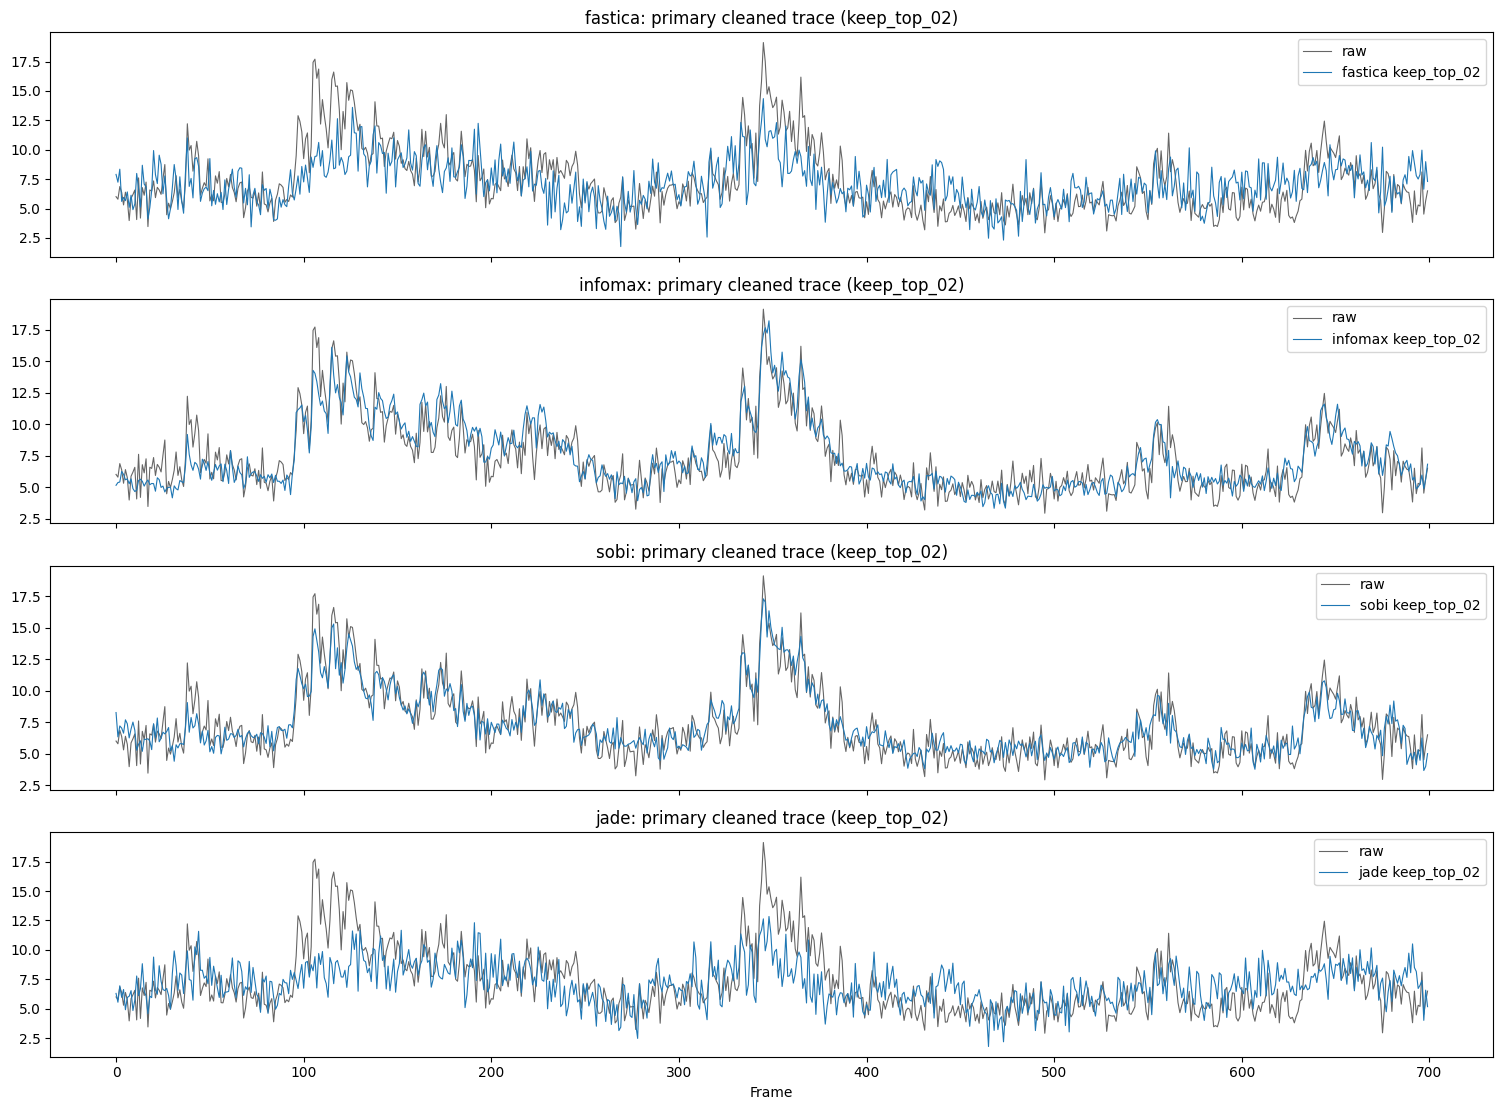

In [8]:
trace_variants = [TraceVariant("raw", dataset.trace_path, traces.T)]
for method, selections in clustered_cleaned_by_selection.items():
    for selection_id, cleaned in selections.items():
        variant_path = saved_paths_by_method.get(method, {}).get(selection_id, {}).get(
            "cleaned",
            Path(method) / selection_id,
        )
        trace_variants.append(TraceVariant(f"{method}_{selection_id}", variant_path, cleaned))
    if method in clustered_cleaned:
        canonical_path = saved_paths.get(method, {}).get("cleaned", Path(method))
        trace_variants.append(TraceVariant(method, canonical_path, clustered_cleaned[method]))

trace_preservation = summarize_trace_preservation(trace_variants, reference_name="raw")
trace_metrics_path = dataset_output_dir / "clustering_trace_preservation.csv"
if SAVE_OUTPUTS:
    trace_preservation.to_csv(trace_metrics_path, index=False)
print(f"Trace metrics: {trace_metrics_path.relative_to(PROJECT_ROOT)}")
display(trace_preservation)

fig, axes = plt.subplots(len(clustered_cleaned), 1, figsize=(15, 2.8 * len(clustered_cleaned)), sharex=True)
axes = np.atleast_1d(axes)
neuron = 0
stop = min(700, traces.shape[1])
for ax, (method, cleaned) in zip(axes, clustered_cleaned.items()):
    selection_id = primary_selection_id_by_method.get(method, "primary")
    ax.plot(traces[neuron, :stop], label="raw", color="black", alpha=0.6, lw=0.8)
    ax.plot(cleaned[:stop, neuron], label=f"{method} {selection_id}", lw=0.8)
    ax.set_title(f"{method}: primary cleaned trace ({selection_id})")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Frame")
fig.tight_layout()
trace_comparison_path = figure_dir / f"cluster_cleaned_trace_comparison_{dataset.data_name}.png"
if SAVE_OUTPUTS:
    fig.savefig(trace_comparison_path, dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved trace comparison plot: {trace_comparison_path.relative_to(PROJECT_ROOT)}")
